# Visualizations and Business Insights

This notebook visualizes the strongest findings from the SQL business analysis. The goal is to communicate the main business patterns around order volume, delivery reliability, customer satisfaction, and product-category performance.

This version keeps the notebook focused while using more advanced Seaborn visuals where they add real analytical value.

In [1]:
import pandas as pd
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH = Path("../data/processed/olist.db")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(DB_PATH)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05
)

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
def save_figure(fig, filename):
    """
    Save a matplotlib figure to the reports/figures folder.
    """
    fig.savefig(
        FIGURES_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )


def format_thousands_axis(ax, axis="y"):
    """
    Format large axis values with comma separators.
    """
    if axis == "y":
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{int(x):,}")
        )
    elif axis == "x":
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{int(x):,}")
        )

## Visualization Plan

The SQL analysis produced many useful tables, but only the strongest results are visualized here. The selected charts focus on:

- order volume trends
- late delivery patterns over time and geography
- the relationship between delivery performance and review scores
- product-category revenue and customer experience

Some simpler bar charts were intentionally replaced with richer distribution and heatmap visuals to avoid repeating the same chart type too often.

## Monthly Order Trend

This chart shows how order volume changed over time. Partial months at the beginning and end of the dataset are excluded from the visualization to avoid misleading trend interpretation.

In [3]:
monthly_orders_query = """
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS purchase_month,
    COUNT(*) AS total_orders
FROM orders
GROUP BY purchase_month
ORDER BY purchase_month;
"""

monthly_orders_df = pd.read_sql_query(monthly_orders_query, conn)

monthly_orders_filtered_df = monthly_orders_df[
    (monthly_orders_df["purchase_month"] >= "2017-01") &
    (monthly_orders_df["purchase_month"] <= "2018-08")
].copy()

monthly_orders_filtered_df

,purchase_month,total_orders
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026
10,2017-08,4331
11,2017-09,4285
12,2017-10,4631


In [4]:
def plot_monthly_order_trend(df):
    fig, ax = plt.subplots(figsize=(12, 5))

    sns.lineplot(
        data=df,
        x="purchase_month",
        y="total_orders",
        marker="o",
        linewidth=2.3,
        color="#31688e",
        ax=ax
    )

    ax.set_title(
        "Monthly Order Volume",
        fontsize=15,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Purchase Month")
    ax.set_ylabel("Total Orders")
    ax.tick_params(axis="x", rotation=45)

    format_thousands_axis(ax, axis="y")

    ax.grid(True, axis="y", alpha=0.3)
    ax.grid(False, axis="x")

    sns.despine(ax=ax)
    fig.tight_layout()

    save_figure(fig, "monthly_order_volume.png")

    return fig, ax

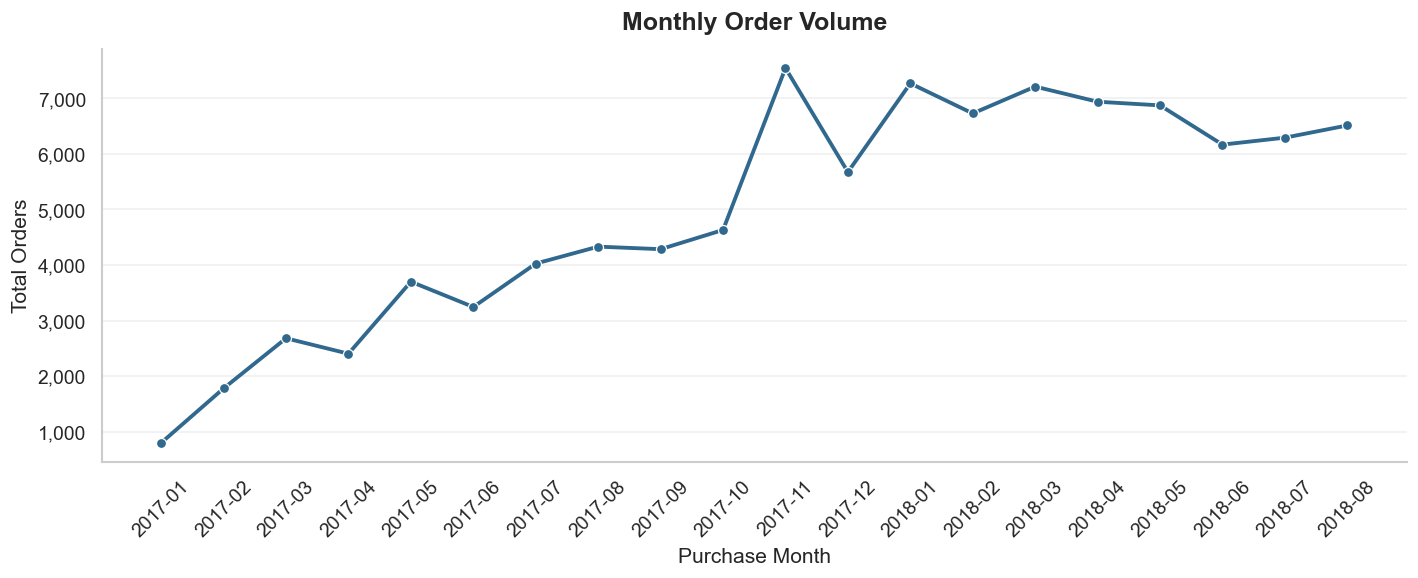

In [5]:
fig, ax = plot_monthly_order_trend(monthly_orders_filtered_df)
plt.show()

### Monthly Order Trend Observation

Order volume increased strongly throughout 2017 and remained high through most of 2018. November 2017 was the strongest month in the reliable analysis period.

The earliest and latest months contain very few orders, suggesting they are partial months rather than true business declines. For this reason, the visualization focuses on the more reliable period from 2017-01 to 2018-08.

## Monthly Late Delivery Rate

This chart shows how the late delivery rate changed over time. It helps identify whether late delivery was a constant issue or concentrated in specific operational periods.

In [6]:
monthly_late_delivery_query = """
SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) AS purchase_month,
    COUNT(*) AS total_delivered_orders,
    SUM(
        CASE
            WHEN julianday(o.order_delivered_customer_date) > julianday(o.order_estimated_delivery_date) THEN 1 
            ELSE 0 
        END
    ) AS late_orders,
    ROUND(
        100.0 * SUM(
            CASE 
                WHEN julianday(o.order_delivered_customer_date) > julianday(o.order_estimated_delivery_date) THEN 1 
                ELSE 0 
            END
        ) / COUNT(*),
        2
    ) AS late_order_percentage
FROM orders AS o
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
GROUP BY purchase_month
ORDER BY purchase_month ASC;
"""

monthly_late_delivery_df = pd.read_sql_query(
    monthly_late_delivery_query,
    conn
)

monthly_late_delivery_filtered_df = monthly_late_delivery_df[
    (monthly_late_delivery_df["purchase_month"] >= "2017-01") &
    (monthly_late_delivery_df["purchase_month"] <= "2018-08")
].copy()

monthly_late_delivery_filtered_df

,purchase_month,total_delivered_orders,late_orders,late_order_percentage
3,2017-01,750,23,3.07
4,2017-02,1653,53,3.21
5,2017-03,2546,142,5.58
6,2017-04,2303,181,7.86
7,2017-05,3545,128,3.61
8,2017-06,3135,121,3.86
9,2017-07,3872,133,3.43
10,2017-08,4193,139,3.32
11,2017-09,4150,216,5.20
12,2017-10,4478,237,5.29


In [7]:
def plot_monthly_late_delivery_rate(df):
    fig, ax = plt.subplots(figsize=(12, 5))

    sns.lineplot(
        data=df,
        x="purchase_month",
        y="late_order_percentage",
        marker="o",
        linewidth=2.3,
        color="#b03a2e",
        ax=ax
    )

    ax.set_title(
        "Monthly Late Delivery Rate",
        fontsize=15,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Purchase Month")
    ax.set_ylabel("Late Delivery Rate (%)")
    ax.tick_params(axis="x", rotation=45)

    ax.grid(True, axis="y", alpha=0.3)
    ax.grid(False, axis="x")

    sns.despine(ax=ax)
    fig.tight_layout()

    save_figure(fig, "monthly_late_delivery_rate.png")

    return fig, ax

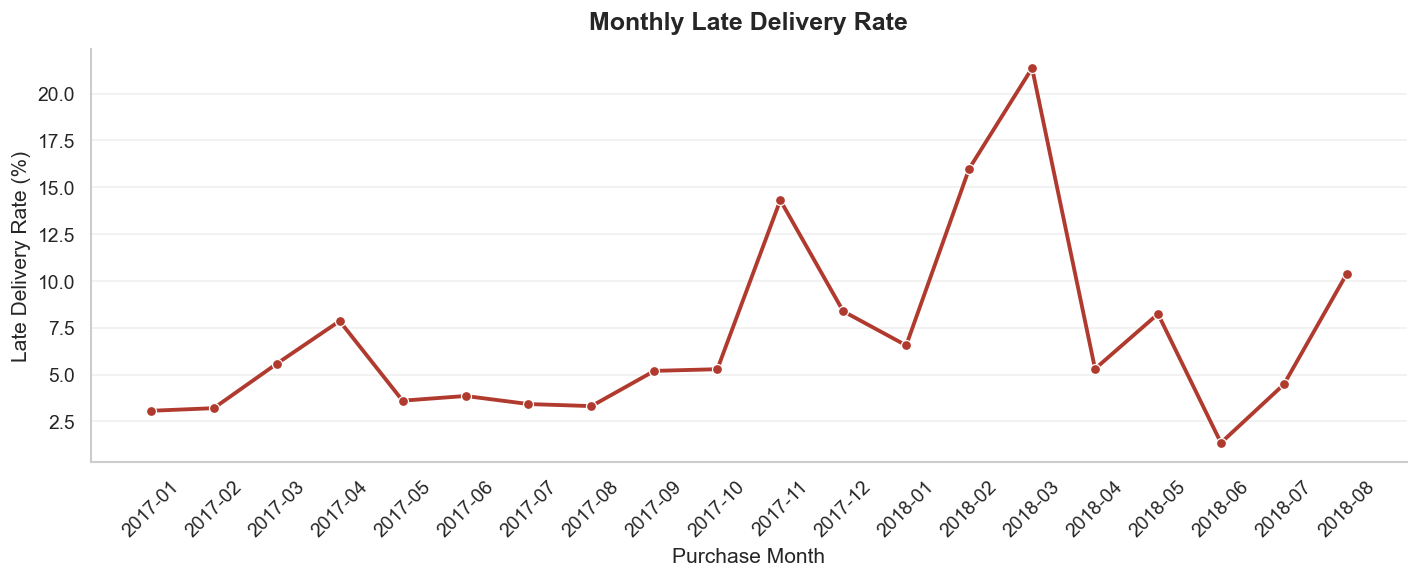

In [8]:
fig, ax = plot_monthly_late_delivery_rate(monthly_late_delivery_filtered_df)
plt.show()

### Monthly Late Delivery Rate Observation

Late delivery rates vary significantly across months. Several periods show major spikes, especially November 2017, February 2018, March 2018, and August 2018.

March 2018 has the highest meaningful late delivery rate in the reliable period, suggesting that late delivery was not a constant baseline issue but became much worse during specific operational periods.

## Delivery Time Distribution by Review Score

This violin plot compares the distribution of delivery times across review scores. Delivery days are capped at 60 days in the visualization to focus on typical deliveries and avoid extreme outliers dominating the scale.

In [9]:
delivery_days_reviews_query = """
SELECT 
    r.review_score,
    julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp) AS delivery_days,
    CASE
        WHEN julianday(o.order_delivered_customer_date) <= julianday(o.order_estimated_delivery_date) THEN 'Early / On Time'
        ELSE 'Late'
    END AS delivery_status
FROM orders AS o
INNER JOIN reviews AS r
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
  AND r.review_score IS NOT NULL;
"""

delivery_days_reviews_df = pd.read_sql_query(
    delivery_days_reviews_query,
    conn
)

typical_delivery_days_reviews_df = delivery_days_reviews_df[
    delivery_days_reviews_df["delivery_days"] <= 60
].copy()

typical_delivery_days_reviews_df.head()

,review_score,delivery_days,delivery_status
0,4,8.44,Early / On Time
1,4,13.78,Early / On Time
2,5,9.39,Early / On Time
3,5,13.21,Early / On Time
4,5,2.87,Early / On Time


In [27]:
def plot_delivery_days_by_review_score(df):
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.violinplot(
        data=df,
        x="review_score",
        y="delivery_days",
        hue="review_score",
        inner="quartile",
        cut=0,
        palette="mako",
        legend=False,
        ax=ax
    )

    ax.set_title(
        "Delivery Time Distribution by Review Score",
        fontsize=15,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Review Score")
    ax.set_ylabel("Delivery Days")

    ax.grid(True, axis="y", alpha=0.3)
    ax.grid(False, axis="x")

    sns.despine(ax=ax)
    fig.tight_layout()

    save_figure(fig, "delivery_days_by_review_score_violin.png")

    return fig, ax

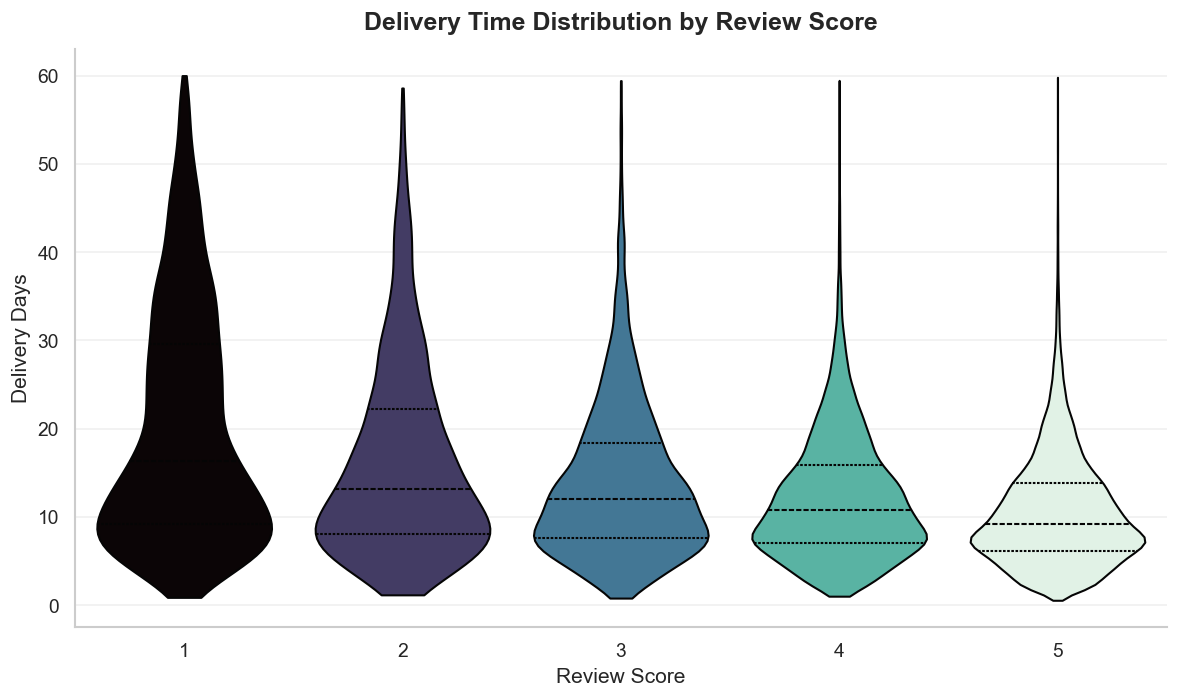

In [28]:
fig, ax = plot_delivery_days_by_review_score(typical_delivery_days_reviews_df)
plt.show()

### Delivery Time Distribution by Review Score Observation

Lower review scores tend to show longer and more spread-out delivery times, while higher review scores are more concentrated around shorter delivery durations.

This supports the earlier SQL finding that slower delivery is associated with weaker customer feedback. The plot focuses on deliveries up to 60 days so that the main distribution is readable without being dominated by rare extreme delays.

## Late Delivery Rate by Customer State and Month

This heatmap checks whether late delivery problems were concentrated in specific customer states during specific months. It focuses on the highest-volume customer states to keep the visualization readable.

In [12]:
state_month_late_delivery_query = """
WITH delivered_orders AS (
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS purchase_month,
        c.customer_state,
        o.order_id,
        CASE
            WHEN julianday(o.order_delivered_customer_date) > julianday(o.order_estimated_delivery_date) THEN 1
            ELSE 0
        END AS is_late
    FROM orders AS o
    INNER JOIN customers AS c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
      AND strftime('%Y-%m', o.order_purchase_timestamp) BETWEEN '2017-01' AND '2018-08'
),
top_states AS (
    SELECT
        customer_state
    FROM delivered_orders
    GROUP BY customer_state
    ORDER BY COUNT(*) DESC
    LIMIT 8
)
SELECT
    d.purchase_month,
    d.customer_state,
    COUNT(*) AS total_delivered_orders,
    SUM(d.is_late) AS late_orders,
    ROUND(100.0 * SUM(d.is_late) / COUNT(*), 2) AS late_order_percentage
FROM delivered_orders AS d
WHERE d.customer_state IN (
    SELECT customer_state
    FROM top_states
)
GROUP BY d.purchase_month, d.customer_state
ORDER BY d.customer_state, d.purchase_month;
"""

state_month_late_delivery_df = pd.read_sql_query(
    state_month_late_delivery_query,
    conn
)

state_month_late_delivery_pivot = state_month_late_delivery_df.pivot(
    index="customer_state",
    columns="purchase_month",
    values="late_order_percentage"
)

state_month_late_delivery_pivot

purchase_month,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
customer_state,,,,,,,,,,,,,,,,,,,,
BA,4.17,8.62,10.34,17.86,5.04,8.74,5.56,3.29,19.16,10.76,16.87,14.36,7.46,21.63,35.32,24.54,21.52,7.07,6.94,1.26
DF,15.38,0.00,0.00,0.00,1.67,2.90,0.00,1.20,10.64,5.43,12.74,5.43,4.44,14.71,20.41,4.11,12.14,0.68,4.24,4.90
MG,0.00,0.83,3.21,2.63,1.70,1.69,1.38,2.40,1.01,1.29,9.76,4.04,3.78,10.51,23.25,2.96,11.58,0.14,1.71,3.14
PR,3.23,3.64,4.13,3.57,1.46,1.20,1.03,0.00,0.57,4.55,10.14,5.38,2.96,9.85,15.18,1.57,10.71,0.00,2.55,4.89
RJ,4.40,3.91,5.14,8.00,3.43,3.76,3.66,3.35,5.92,8.26,28.06,26.14,14.71,35.95,36.92,5.95,8.09,1.41,3.59,8.30
RS,1.92,3.00,2.78,3.03,0.98,2.33,2.48,8.11,2.93,4.10,15.65,11.51,9.26,14.60,20.64,3.48,3.43,1.32,1.95,4.78
SC,3.85,5.26,21.15,13.00,5.48,4.59,5.26,3.95,8.50,5.17,15.97,6.25,11.58,25.98,23.48,2.45,7.96,0.00,2.05,5.97
SP,2.83,3.16,3.21,8.36,5.14,4.28,2.46,2.40,3.87,4.12,8.45,3.57,3.97,8.62,11.68,2.10,5.48,0.95,5.31,15.61


In [13]:
def plot_state_month_late_delivery_heatmap(pivot_df):
    fig, ax = plt.subplots(figsize=(13, 6))

    sns.heatmap(
        pivot_df,
        cmap="rocket_r",
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "Late Delivery Rate (%)"},
        ax=ax
    )

    ax.set_title(
        "Late Delivery Rate by Customer State and Month",
        fontsize=15,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Purchase Month")
    ax.set_ylabel("Customer State")

    ax.tick_params(axis="x", rotation=45)

    fig.tight_layout()

    save_figure(fig, "late_delivery_heatmap_state_month.png")

    return fig, ax

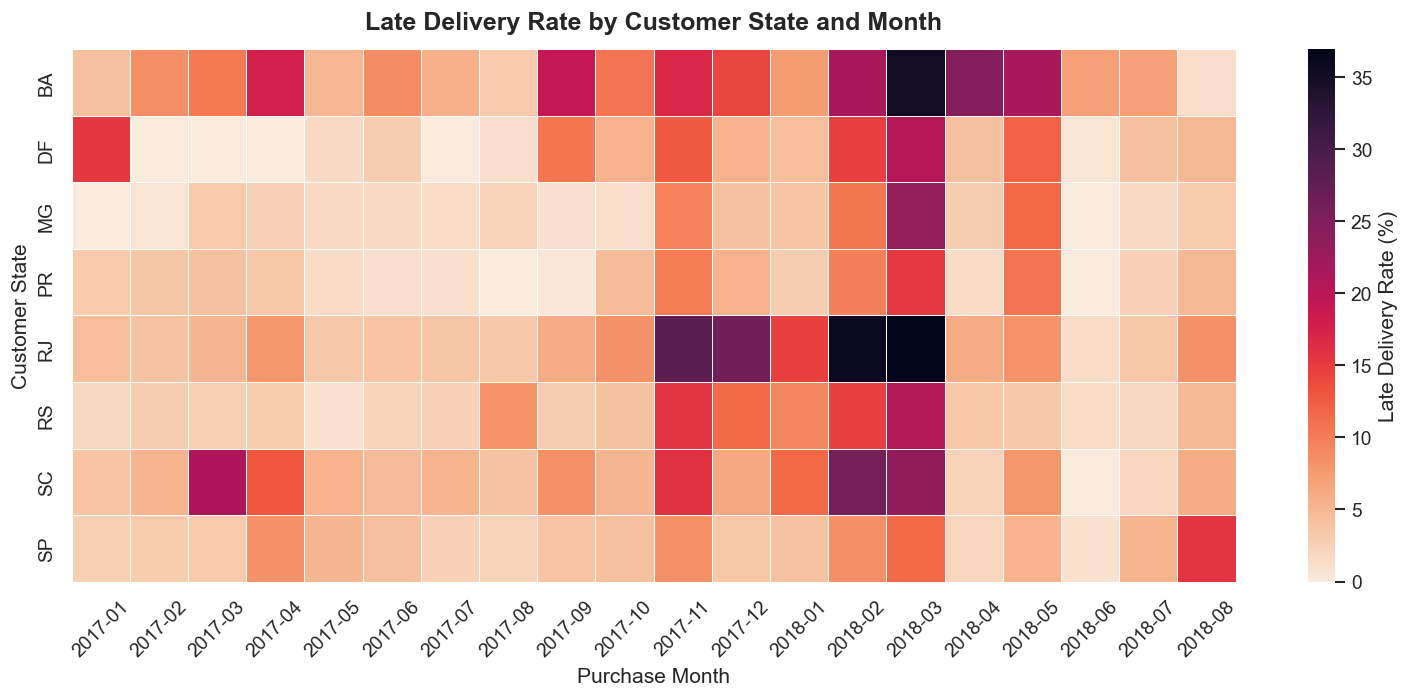

In [14]:
fig, ax = plot_state_month_late_delivery_heatmap(state_month_late_delivery_pivot)
plt.show()

### Late Delivery Heatmap Observation

Late delivery problems were not evenly distributed across time or geography. Some months show broader late-delivery spikes, while certain customer states appear more affected than others.

This suggests that late delivery may be linked to regional logistics conditions, seller-to-customer distance, carrier coverage, or temporary operational stress during specific months.

## Late Delivery and Review Scores

This chart compares average review scores for orders delivered on time versus orders delivered after the estimated delivery date.

In [15]:
late_delivery_reviews_query = """
WITH delivered_reviews AS (
    SELECT 
        o.order_id,
        r.review_id,
        r.review_score,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date
    FROM orders AS o
    INNER JOIN reviews AS r 
        ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
      AND r.review_score IS NOT NULL
),
status_mapped_reviews AS (
    SELECT 
        order_id,
        review_id,
        review_score,
        CASE 
            WHEN julianday(order_delivered_customer_date) <= julianday(order_estimated_delivery_date) THEN 'Early / On Time'
            ELSE 'Late'
        END AS delivery_status
    FROM delivered_reviews
)
SELECT 
    delivery_status,
    COUNT(*) AS total_reviews,
    ROUND(AVG(review_score), 2) AS avg_review_score
FROM status_mapped_reviews
GROUP BY delivery_status
ORDER BY avg_review_score DESC;
"""

late_delivery_reviews_df = pd.read_sql_query(
    late_delivery_reviews_query,
    conn
)

late_delivery_reviews_df

,delivery_status,total_reviews,avg_review_score
0,Early / On Time,88653,4.29
1,Late,7700,2.57


In [16]:
def plot_late_delivery_review_score(df):
    fig, ax = plt.subplots(figsize=(7, 5))

    sns.barplot(
        data=df,
        x="delivery_status",
        y="avg_review_score",
        hue="delivery_status",
        palette=["#2e7d32", "#c0392b"],
        legend=False,
        ax=ax
    )

    ax.set_title(
        "Average Review Score by Delivery Status",
        fontsize=15,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Delivery Status")
    ax.set_ylabel("Average Review Score")
    ax.set_ylim(0, 5)

    ax.grid(True, axis="y", alpha=0.3)
    ax.grid(False, axis="x")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=3,
            fontsize=10
        )

    sns.despine(ax=ax)
    fig.tight_layout()

    save_figure(fig, "review_score_by_delivery_status.png")

    return fig, ax

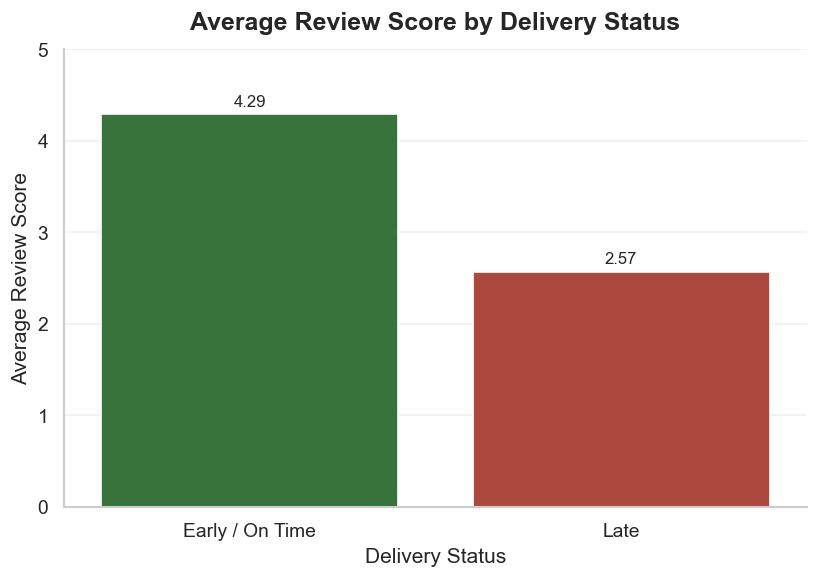

In [17]:
fig, ax = plot_late_delivery_review_score(late_delivery_reviews_df)
plt.show()

### Late Delivery and Review Score Observation

Orders delivered early or on time received much higher average review scores than late deliveries. This suggests that meeting the estimated delivery promise is strongly associated with customer satisfaction.

This does not prove that late delivery is the only cause of lower reviews, since product quality, seller behavior, and customer expectations may also affect ratings. However, delivery reliability appears to be an important part of the customer experience.

## Top Product Categories by Revenue

This chart identifies the delivered-order product categories that generated the highest product revenue. Product revenue is calculated using item price only and does not include freight value.

In [18]:
top_categories_revenue_query = """
SELECT 
    ct.product_category_name_english,
    ROUND(SUM(oi.price), 2) AS total_product_revenue,
    COUNT(*) AS total_items,
    ROUND(AVG(oi.price), 2) AS avg_item_price
FROM orders AS o
INNER JOIN order_items AS oi 
    ON o.order_id = oi.order_id
INNER JOIN products AS p 
    ON oi.product_id = p.product_id
INNER JOIN category_translation AS ct 
    ON p.product_category_name = ct.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY ct.product_category_name_english
ORDER BY total_product_revenue DESC
LIMIT 10;
"""

top_categories_revenue_df = pd.read_sql_query(
    top_categories_revenue_query,
    conn
)

top_categories_revenue_df

,product_category_name_english,total_product_revenue,total_items,avg_item_price
0,health_beauty,"1,233,131.72",9465,130.28
1,watches_gifts,"1,166,176.98",5859,199.04
2,bed_bath_table,"1,023,434.76",10953,93.44
3,sports_leisure,"954,852.55",8431,113.25
4,computers_accessories,"888,724.61",7644,116.26
5,furniture_decor,"711,927.69",8160,87.25
6,housewares,"615,628.69",6795,90.60
7,cool_stuff,"610,204.10",3718,164.12
8,auto,"578,966.65",4140,139.85
9,toys,"471,286.48",4030,116.94


In [19]:
def plot_top_categories_by_revenue(df):
    plot_df = df.sort_values("total_product_revenue", ascending=True).copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=plot_df,
        x="total_product_revenue",
        y="product_category_name_english",
        hue="product_category_name_english",
        palette="crest",
        legend=False,
        ax=ax
    )

    ax.set_title(
        "Top Product Categories by Revenue",
        fontsize=15,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Product Revenue")
    ax.set_ylabel("Product Category")

    format_thousands_axis(ax, axis="x")

    ax.grid(True, axis="x", alpha=0.3)
    ax.grid(False, axis="y")

    sns.despine(ax=ax)
    fig.tight_layout()

    save_figure(fig, "top_categories_by_revenue.png")

    return fig, ax

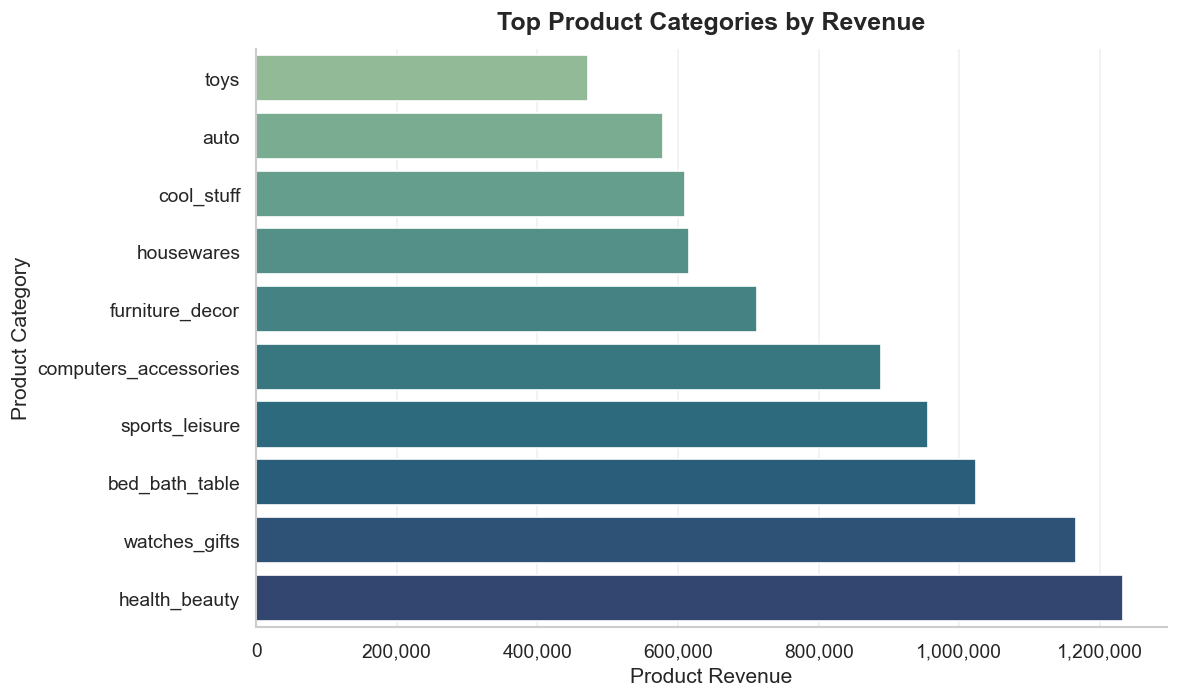

In [20]:
fig, ax = plot_top_categories_by_revenue(top_categories_revenue_df)
plt.show()

### Top Product Categories by Revenue Observation

Health/beauty generated the highest product revenue among delivered orders, followed by watches/gifts and bed/bath/table. However, the top categories do not all follow the same revenue pattern.

Health/beauty combines high order-item volume with a relatively strong average item price, while watches/gifts generates high revenue with fewer items because of its higher average item price. Bed/bath/table appears more volume-driven, with very high item volume but a lower average item price.

## Category Performance Summary

This scatterplot compares product revenue and average review score across top categories. Bubble size represents item-review volume, while color represents late item percentage.

In [21]:
category_performance_summary_query = """
SELECT 
    ct.product_category_name_english,
    COUNT(*) AS total_item_reviews,
    ROUND(SUM(oi.price), 2) AS total_product_revenue,
    ROUND(AVG(oi.price), 2) AS avg_item_price,
    ROUND(
        100.0 * SUM(
            CASE 
                WHEN julianday(o.order_delivered_customer_date) > julianday(o.order_estimated_delivery_date) THEN 1 
                ELSE 0 
            END
        ) / COUNT(*),
        2
    ) AS late_item_percentage,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM orders AS o
INNER JOIN order_items AS oi 
    ON o.order_id = oi.order_id
INNER JOIN products AS p 
    ON oi.product_id = p.product_id
INNER JOIN category_translation AS ct 
    ON p.product_category_name = ct.product_category_name
INNER JOIN reviews AS r 
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND o.order_estimated_delivery_date IS NOT NULL
  AND r.review_score IS NOT NULL
GROUP BY ct.product_category_name_english
HAVING COUNT(*) >= 500
ORDER BY total_product_revenue DESC
LIMIT 15;
"""

category_performance_summary_df = pd.read_sql_query(
    category_performance_summary_query,
    conn
)

category_performance_summary_df

,product_category_name_english,total_item_reviews,total_product_revenue,avg_item_price,late_item_percentage,avg_review_score
0,health_beauty,9456,"1,228,986.81",129.97,8.86,4.19
1,watches_gifts,5823,"1,160,011.57",199.21,8.14,4.07
2,bed_bath_table,10985,"1,027,333.65",93.52,8.25,3.92
3,sports_leisure,8435,"954,117.99",113.11,7.30,4.17
4,computers_accessories,7671,"892,168.64",116.30,7.63,3.99
5,furniture_decor,8159,"712,414.53",87.32,8.27,3.95
6,housewares,6780,"613,843.72",90.54,6.36,4.11
7,cool_stuff,3698,"605,088.81",163.63,6.63,4.19
8,auto,4116,"572,632.84",139.12,8.24,4.12
9,garden_tools,4254,"468,477.18",110.13,7.90,4.08


In [22]:
def plot_category_performance_summary(df):
    fig, ax = plt.subplots(figsize=(11, 6))

    sns.scatterplot(
        data=df,
        x="total_product_revenue",
        y="avg_review_score",
        size="total_item_reviews",
        hue="late_item_percentage",
        sizes=(90, 650),
        palette="rocket_r",
        alpha=0.85,
        ax=ax
    )

    labels_to_show = [
        "health_beauty",
        "watches_gifts",
        "bed_bath_table",
        "office_furniture",
        "cool_stuff"
    ]

    for _, row in df[df["product_category_name_english"].isin(labels_to_show)].iterrows():
        ax.text(
            row["total_product_revenue"],
            row["avg_review_score"] + 0.02,
            row["product_category_name_english"],
            fontsize=8.5,
            ha="center"
        )

    ax.set_title(
        "Category Revenue vs Customer Satisfaction",
        fontsize=15,
        fontweight="bold",
        pad=12
    )
    ax.set_xlabel("Product Revenue")
    ax.set_ylabel("Average Review Score")

    ax.set_ylim(
        df["avg_review_score"].min() - 0.15,
        df["avg_review_score"].max() + 0.15
    )

    format_thousands_axis(ax, axis="x")

    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles,
        labels=labels,
        title="Late % / Volume",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    sns.despine(ax=ax)
    fig.tight_layout()

    save_figure(fig, "category_performance_summary_scatter.png")

    return fig, ax

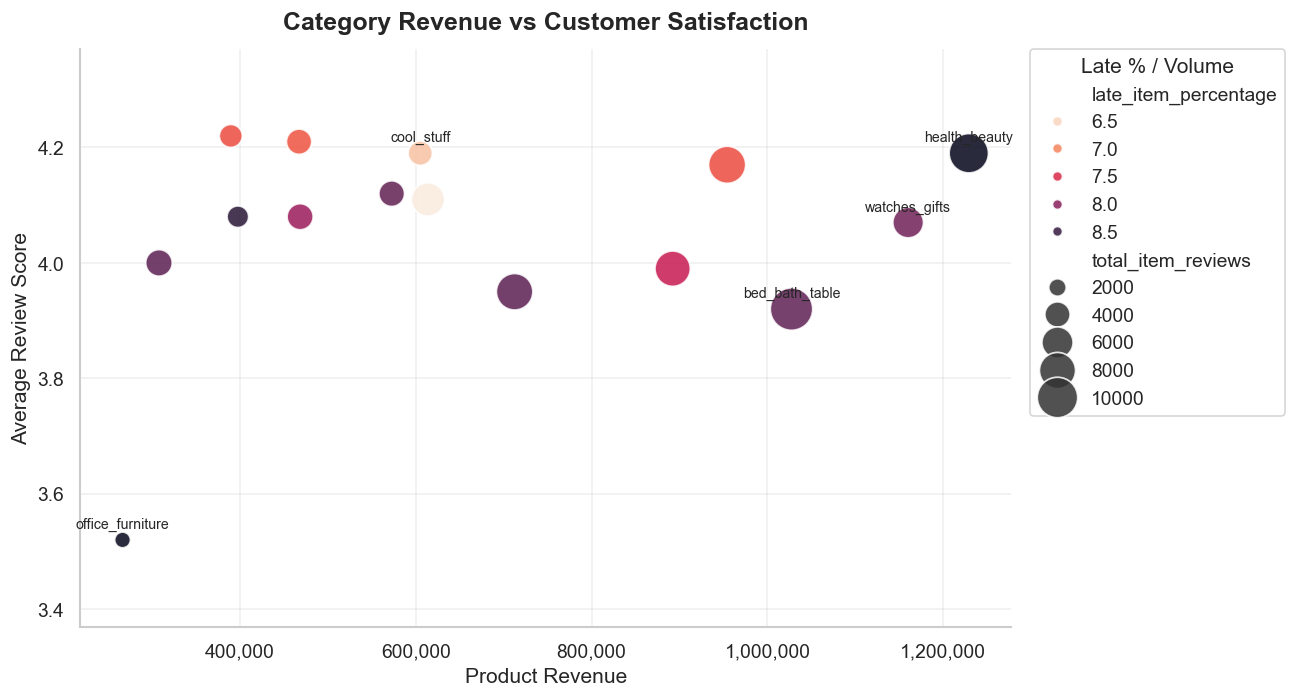

In [23]:
fig, ax = plot_category_performance_summary(category_performance_summary_df)
plt.show()

### Category Performance Summary Observation

Health/beauty appears to be one of the strongest overall categories. It generates the highest product revenue among the top categories while maintaining a solid average review score. However, it also has a relatively high late item percentage, suggesting that even strong revenue categories may still have delivery reliability issues.

Watches/gifts is also a major revenue contributor, but its performance is more price-driven because it has a high average item price compared to many other categories.

Bed/bath/table is one of the most important categories to monitor. It has very high item-review volume and strong revenue contribution, but its average review score is weaker than many other top categories and its late item percentage is also relatively high.

Overall, category performance should not be judged by revenue alone. The strongest business categories are not always the strongest customer-experience categories, so revenue, item volume, delivery reliability, and review score should be evaluated together.

## Final Visualization Summary

The visual analysis highlights three main findings:

1. Order volume increased strongly through 2017 and remained high through most of 2018, with edge months treated as partial data.
2. Delivery reliability is strongly connected to customer satisfaction. Late and slow deliveries are associated with much lower review scores, and late delivery issues vary by time period and customer state.
3. Product categories differ in business role. Some categories are revenue leaders, some are volume-driven, and some require attention because they combine high business importance with weaker customer experience metrics.